# Notebook 10 — Syndrome Transformer Decoder

**Motivation:**  
The LSTM processes syndrome rounds sequentially — it can only look backwards.  
A Transformer uses **self-attention**: every syndrome round attends to every other round simultaneously.  
This is the architecture behind AlphaQubit (Bausch et al., Nature 2024 / arXiv:2310.05900),  
the current state-of-the-art neural decoder for surface codes.

**Our simplified architecture** (scaled for d=3 teaching purposes):
```
Input     : (N, 9 rounds, 8 stabilisers)
Embedding : Linear(8 → d_model=64)  per round
Positional: learnable position embedding (9 positions)
Transformer: 2 encoder layers, 4 heads, d_ff=128, dropout=0.1
Pooling   : mean over rounds
Head      : Linear(64→32) → ReLU → Linear(32→1)
```

**Why this should beat the LSTM:**  
In round 5, the LSTM has forgotten details from round 1 (vanishing hidden state).  
The Transformer can directly attend from round 5 back to round 1 with full fidelity.

**Reference:** Bausch et al., arXiv:2310.05900, Section 2 — Syndrome Transformer.

**Prerequisite:** Run notebook 01 (or 01B for multi-noise).  
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import time, os, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROUNDS, STABS = 9, 8
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Load Data

Uses single-noise data (notebook 01) by default.  
Change `DATA_DIR` to `data/mixed` to use multi-noise data from notebook 01B.

In [2]:
DATA_DIR = "data"          # ← change to "data/mixed" for multi-noise training

det = np.load(f"{DATA_DIR}/detection_events.npy").astype(np.float32)
obs = np.load(f"{DATA_DIR}/observable_flips.npy").astype(np.float32).squeeze()

# Reshape for transformer: (N, 72) → (N, 9 rounds, 8 stabilisers)
det_seq = det.reshape(-1, ROUNDS, STABS)

idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs[idx_tmp].astype(int), random_state=SEED)

seq_tr,  obs_tr  = det_seq[idx_tr],  obs[idx_tr]
seq_val, obs_val = det_seq[idx_val], obs[idx_val]
seq_te,  obs_te  = det_seq[idx_te],  obs[idx_te]
trivial_ler = obs_te.mean()

print(f"Data source : {DATA_DIR}")
print(f"Sequence shape : {det_seq.shape}  (N, rounds, stabilisers)")
print(f"Split → train: {len(idx_tr):,}  val: {len(idx_val):,}  test: {len(idx_te):,}")
print(f"Trivial LER : {trivial_ler:.4f}")

Data source : data
Sequence shape : (100000, 9, 8)  (N, rounds, stabilisers)
Split → train: 70,000  val: 15,000  test: 15,000
Trivial LER : 0.0549


---
## 2. Transformer Model

**Key design choices (following Bausch et al.):**
- **Per-stabiliser embedding** — each round's 8 syndrome bits are projected to a d_model vector
- **Learnable positional embedding** — encodes which round each token came from
- **Multi-head self-attention** — every round attends to every other round
- **Mean pooling** — aggregates across all rounds to produce a single vector for classification

In [3]:
class SyndromeTransformer(nn.Module):
    """
    Transformer-based surface code decoder.

    Input : (batch, rounds=9, stabilisers=8)
    Output: (batch,) raw logit

    Architecture simplified from Bausch et al. arXiv:2310.05900:
      - Linear embedding per round
      - Learnable positional embedding
      - Transformer encoder (self-attention over rounds)
      - Mean pool → classification head
    """
    def __init__(self,
                 input_size  = 8,      # stabilisers per round
                 num_rounds  = 9,      # sequence length
                 d_model     = 64,     # embedding dimension
                 nhead       = 4,      # attention heads  (d_model must be divisible by nhead)
                 num_layers  = 2,      # transformer encoder layers
                 d_ff        = 128,    # feedforward hidden dim
                 dropout     = 0.1):
        super().__init__()

        # Project 8 syndrome bits → d_model embedding per round
        self.input_proj = nn.Linear(input_size, d_model)

        # Learnable position embedding: one vector per round position
        self.pos_embed  = nn.Embedding(num_rounds, d_model)

        # Transformer encoder: self-attention over the 9 round tokens
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = nhead,
            dim_feedforward = d_ff,
            dropout    = dropout,
            batch_first = True,       # (batch, seq, d_model)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers)

        # Classification head applied after mean-pooling
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

        self._init_weights()

    def _init_weights(self):
        """Xavier init for linear layers, normal for embeddings."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, x):
        # x: (batch, rounds, stabilisers)
        batch, rounds, _ = x.shape

        # Embed each round's syndromes
        tok = self.input_proj(x)   # (batch, rounds, d_model)

        # Add positional embedding
        pos = torch.arange(rounds, device=x.device)          # (rounds,)
        tok = tok + self.pos_embed(pos).unsqueeze(0)          # broadcast over batch

        # Self-attention: every round attends to every other round
        enc = self.transformer(tok)   # (batch, rounds, d_model)

        # Mean-pool over rounds → (batch, d_model)
        pooled = enc.mean(dim=1)

        return self.head(pooled).squeeze(-1)   # (batch,)


demo = SyndromeTransformer()
total_params = sum(p.numel() for p in demo.parameters())
print(f"Syndrome Transformer: {total_params:,} parameters")
print()
print("Parameter breakdown:")
for name, p in demo.named_parameters():
    print(f"  {name:<40} {p.numel():>8,}")

# Quick forward pass sanity check
x_test = torch.randn(4, 9, 8)
out    = demo(x_test)
print(f"\nForward pass: input {x_test.shape} → output {out.shape}  ✓")

Syndrome Transformer: 70,209 parameters

Parameter breakdown:
  input_proj.weight                             512
  input_proj.bias                                64
  pos_embed.weight                              576
  transformer.layers.0.self_attn.in_proj_weight   12,288
  transformer.layers.0.self_attn.in_proj_bias      192
  transformer.layers.0.self_attn.out_proj.weight    4,096
  transformer.layers.0.self_attn.out_proj.bias       64
  transformer.layers.0.linear1.weight         8,192
  transformer.layers.0.linear1.bias             128
  transformer.layers.0.linear2.weight         8,192
  transformer.layers.0.linear2.bias              64
  transformer.layers.0.norm1.weight              64
  transformer.layers.0.norm1.bias                64
  transformer.layers.0.norm2.weight              64
  transformer.layers.0.norm2.bias                64
  transformer.layers.1.self_attn.in_proj_weight   12,288
  transformer.layers.1.self_attn.in_proj_bias      192
  transformer.layers.1.self_

---
## 3. Train Transformer

In [4]:
def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)


model      = SyndromeTransformer().to(DEVICE)
optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Warmup + cosine decay — standard for transformers
scheduler  = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3,
    steps_per_epoch=len(make_loader(seq_tr, obs_tr)),
    epochs=120, pct_start=0.05)
pos_weight = torch.tensor([(1-obs_tr.mean())/obs_tr.mean()]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

tr_loader  = make_loader(seq_tr,  obs_tr)
val_loader = make_loader(seq_val, obs_val, shuffle=False)

EPOCHS, PATIENCE = 120, 15
history = {'tr_loss': [], 'val_loss': [], 'tr_ler': [], 'val_ler': []}
best_val_loss, best_epoch, best_state = np.inf, 0, None
t0 = time.time()

print("Training Syndrome Transformer...")
for epoch in range(1, EPOCHS+1):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        tc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
        tt += len(yb); tl += loss.item()*len(yb)
    tr_ler = 1 - tc/tt

    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            vl += criterion(logits, yb).item()*len(yb)
            vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            vt += len(yb)
    val_ler  = 1 - vc/vt
    val_loss = vl/vt

    for k, v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                    [tl/tt, val_loss, tr_ler, val_ler]):
        history[k].append(v)

    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:3d}  tr_LER={tr_ler:.5f}  "
              f"val_LER={val_ler:.5f}  lr={lr_now:.2e}")

    if epoch - best_epoch >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best={best_epoch})")
        break

model.load_state_dict(best_state)
pred_tr = predict(model, seq_te)
ler_transformer = float((pred_tr != obs_te).mean())

print(f"\nDone in {time.time()-t0:.1f}s | best epoch={best_epoch}")
print(f"  Transformer Test LER : {ler_transformer:.5f}  ({100*ler_transformer:.4f}%)")
print(f"  Trivial LER          : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement          : {trivial_ler/ler_transformer:.1f}x")

Training Syndrome Transformer...
  Epoch   1  tr_LER=0.14954  val_LER=0.14940  lr=1.04e-04
  Epoch  20  tr_LER=0.02116  val_LER=0.01493  lr=9.63e-04
  Early stop at epoch 34 (best=19)

Done in 52.2s | best epoch=19
  Transformer Test LER : 0.02300  (2.3000%)
  Trivial LER          : 0.05487  (5.4867%)
  Improvement          : 2.4x


---
## 4. Training Curves

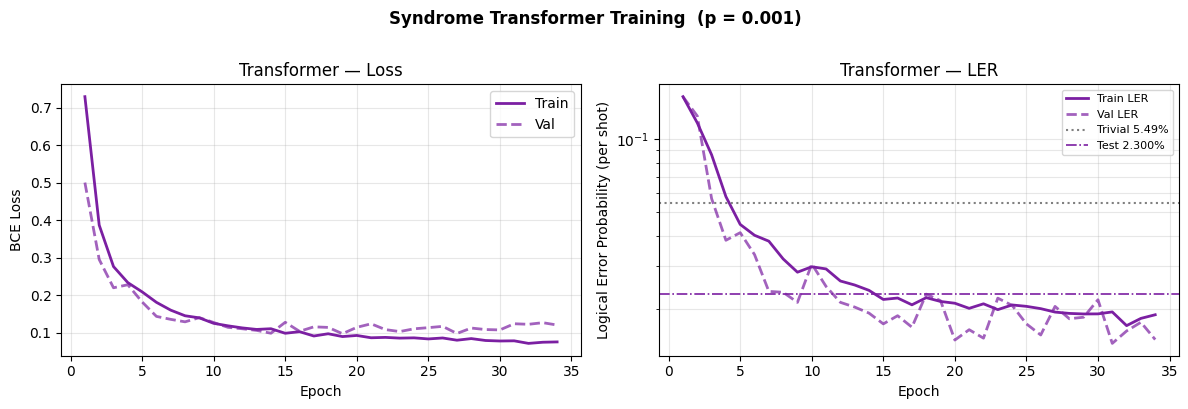

Saved → figures/10_transformer_training.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['tr_loss'])+1)

ax1.plot(ep, history['tr_loss'],  color='#7B1FA2', lw=2, label='Train')
ax1.plot(ep, history['val_loss'], color='#7B1FA2', lw=2, ls='--', alpha=0.7, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Transformer — Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.semilogy(ep, history['tr_ler'],  color='#7B1FA2', lw=2, label='Train LER')
ax2.semilogy(ep, history['val_ler'], color='#7B1FA2', lw=2, ls='--', alpha=0.7, label='Val LER')
ax2.axhline(trivial_ler, color='grey', lw=1.5, ls=':', label=f'Trivial {100*trivial_ler:.2f}%')
ax2.axhline(ler_transformer, color='#7B1FA2', lw=1.2, ls='-.',
            label=f'Test {100*ler_transformer:.3f}%')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Logical Error Probability (per shot)')
ax2.set_title('Transformer — LER'); ax2.legend(fontsize=8); ax2.grid(which='both', alpha=0.3)

plt.suptitle('Syndrome Transformer Training  (p = 0.001)', fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/10_transformer_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/10_transformer_training.png")

---
## 5. Noise Sweep

In [6]:
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
transformer_sweep = []

print("Transformer noise sweep")
print(f"  {'p':>8}  {'Trivial':>10}  {'Transformer':>12}  {'Ratio':>7}")
print("  " + "-"*46)

for p in NOISE_LEVELS:
    tag   = f"{int(p*10000):04d}"
    det_s = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    obs_s = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    seq_s = det_s.reshape(-1, ROUNDS, STABS)
    pred_s = predict(model, seq_s)
    ler_s  = float((pred_s != obs_s).mean())
    triv_s = float(obs_s.mean())
    ratio  = triv_s/ler_s if ler_s > 0 else float('inf')
    transformer_sweep.append((p, ler_s))
    print(f"  p={p:.4f}  {100*triv_s:8.3f}%  {100*ler_s:10.3f}%  {ratio:5.1f}x")

os.makedirs("results", exist_ok=True)
np.save("results/transformer_sweep.npy",
        np.array(transformer_sweep))
print("\nSaved → results/transformer_sweep.npy")

Transformer noise sweep
         p     Trivial   Transformer    Ratio
  ----------------------------------------------
  p=0.0005     2.794%       0.682%    4.1x
  p=0.0010     5.446%       2.178%    2.5x
  p=0.0020    10.400%       6.770%    1.5x
  p=0.0050    21.678%      23.536%    0.9x
  p=0.0100    34.436%      41.154%    0.8x
  p=0.0200    45.288%      49.170%    0.9x

Saved → results/transformer_sweep.npy


---
## 6. Stim-Style Plot — Transformer vs All Previous Decoders

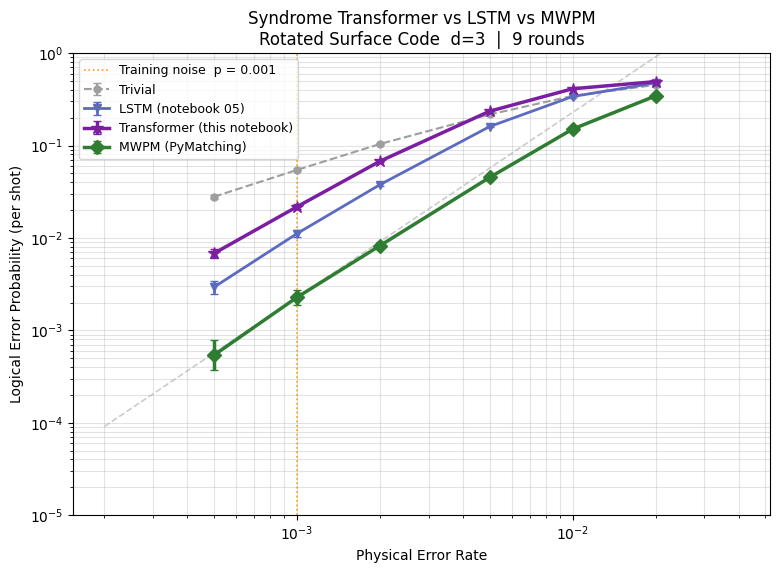

Saved → figures/10_transformer_vs_all.png


In [7]:
def wilson_ci(num_errors, num_shots, z=1.96):
    p = num_errors / num_shots
    denom = 1 + z**2/num_shots
    centre = (p + z**2/(2*num_shots)) / denom
    margin = z*np.sqrt(p*(1-p)/num_shots + z**2/(4*num_shots**2)) / denom
    lo = np.clip(centre-margin, 1e-10, 1.0)
    hi = np.clip(centre+margin, 1e-10, 1.0)
    return float(p-lo), float(hi-p)

def make_yerr(lers, shots=50_000):
    pairs = [wilson_ci(max(1, round(l*shots)), shots) for l in lers]
    lo, hi = zip(*pairs)
    return np.array([lo, hi])

# Load previously computed sweeps
ps = np.array(NOISE_LEVELS)
S  = 50_000

trivials = [np.load(f"data/sweep/obs_p{int(p*10000):04d}.npy").mean()
            for p in NOISE_LEVELS]

try:
    mwpm_data = np.load("results/mwpm_sweep.npy")
    lstm_data = np.load("results/lstm_sweep.npy")
    mwpm_lers = list(mwpm_data[:, 1])
    lstm_lers = list(lstm_data[:, 1])
    have_prev = True
except FileNotFoundError:
    have_prev = False
    print("Previous sweep files not found — plotting transformer only.")

tr_lers = [r[1] for r in transformer_sweep]

fig, ax = plt.subplots(figsize=(9, 6))

# p² reference
if have_prev:
    p_ref = np.array([2e-4, 4e-2])
    ax.plot(p_ref, mwpm_lers[1]*(p_ref/0.001)**2,
            ls='--', color='#CCCCCC', lw=1.2, zorder=0)

ax.errorbar(ps, trivials, yerr=make_yerr(trivials),
            fmt='o--', color='#9E9E9E', lw=1.5, ms=5, capsize=3,
            label='Trivial')

if have_prev:
    ax.errorbar(ps, lstm_lers, yerr=make_yerr(lstm_lers),
                fmt='v-', color='#5C6BC0', lw=2, ms=6, capsize=3,
                label='LSTM (notebook 05)')

ax.errorbar(ps, tr_lers, yerr=make_yerr(tr_lers),
            fmt='*-', color='#7B1FA2', lw=2.5, ms=9, capsize=3,
            label='Transformer (this notebook)')

if have_prev:
    ax.errorbar(ps, mwpm_lers, yerr=make_yerr(mwpm_lers),
                fmt='D-', color='#2E7D32', lw=2.5, ms=7, capsize=3,
                label='MWPM (PyMatching)')

ax.axvline(x=0.001, color='#FF8F00', lw=1.2, ls=':', alpha=0.9,
           label='Training noise  p = 0.001')

ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid(which='both', alpha=0.35)
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.set_title('Syndrome Transformer vs LSTM vs MWPM\n'
             'Rotated Surface Code  d=3  |  9 rounds')
ax.legend(fontsize=9, loc='upper left')

fig.savefig('figures/10_transformer_vs_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/10_transformer_vs_all.png")

---
## 7. Attention Visualisation

Extract and plot what the transformer is attending to —  
which syndrome rounds matter most for the decoding decision?

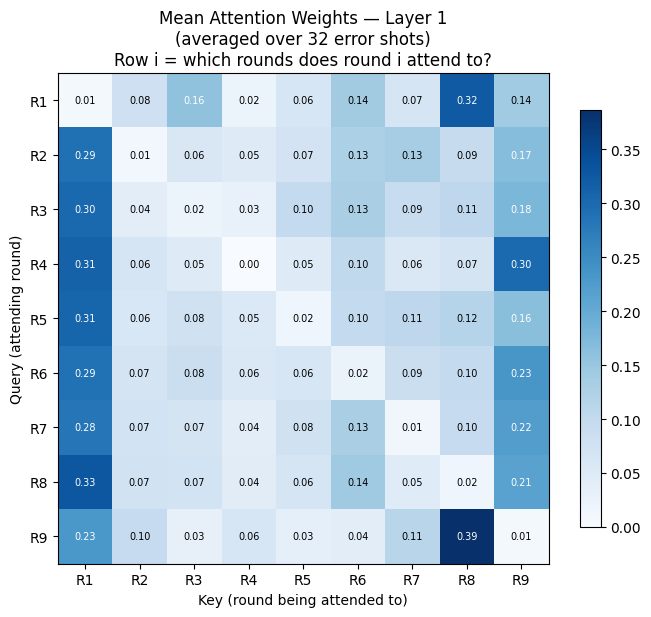

Saved → figures/10_attention_map.png

Interpretation guide:
  Uniform row  → round attends equally to all others (no preference)
  Diagonal peak → round mostly self-attends (local processing)
  Off-diagonal peaks → round uses information from specific other rounds


In [8]:
# Hook to capture attention weights from the first transformer layer
attn_weights = {}

def hook_fn(module, input, output):
    # TransformerEncoderLayer output is just the hidden state
    # We need to re-run attention manually to get weights
    pass

# Simpler approach: use the built-in attn_weight output from MultiheadAttention
class SyndromeTransformerWithAttn(SyndromeTransformer):
    """Same model but exposes attention weights on forward."""
    def forward_with_attn(self, x):
        batch, rounds, _ = x.shape
        tok = self.input_proj(x)
        pos = torch.arange(rounds, device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)

        # Run through first layer only to get attention weights
        layer0 = self.transformer.layers[0]
        tok_norm = layer0.norm1(tok)
        attn_out, attn_w = layer0.self_attn(
            tok_norm, tok_norm, tok_norm,
            need_weights=True, average_attn_weights=True)
        return attn_w   # (batch, rounds, rounds)


# Create a compatible model and load weights
model_attn = SyndromeTransformerWithAttn().to(DEVICE)
model_attn.load_state_dict(model.state_dict())
model_attn.eval()

# Get attention weights on a batch of test shots with errors
error_mask = obs_te == 1
sample_idx = np.where(error_mask)[0][:32]
X_sample   = torch.tensor(seq_te[sample_idx]).to(DEVICE)

with torch.no_grad():
    attn_w = model_attn.forward_with_attn(X_sample)  # (32, 9, 9)

mean_attn = attn_w.cpu().numpy().mean(axis=0)  # (9, 9) averaged over batch

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mean_attn, cmap='Blues', vmin=0)
ax.set_xticks(range(ROUNDS))
ax.set_yticks(range(ROUNDS))
ax.set_xticklabels([f'R{i+1}' for i in range(ROUNDS)])
ax.set_yticklabels([f'R{i+1}' for i in range(ROUNDS)])
ax.set_xlabel('Key (round being attended to)')
ax.set_ylabel('Query (attending round)')
ax.set_title('Mean Attention Weights — Layer 1\n'
             '(averaged over 32 error shots)\n'
             'Row i = which rounds does round i attend to?')
plt.colorbar(im, ax=ax, shrink=0.85)

for i in range(ROUNDS):
    for j in range(ROUNDS):
        ax.text(j, i, f'{mean_attn[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='white' if mean_attn[i,j] > 0.15 else 'black')

plt.tight_layout()
fig.savefig('figures/10_attention_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/10_attention_map.png")
print()
print("Interpretation guide:")
print("  Uniform row  → round attends equally to all others (no preference)")
print("  Diagonal peak → round mostly self-attends (local processing)")
print("  Off-diagonal peaks → round uses information from specific other rounds")

---
## 8. Save Model

In [9]:
os.makedirs("models", exist_ok=True)
torch.save({
    'model_state':  model.state_dict(),
    'input_size':   STABS,
    'num_rounds':   ROUNDS,
    'd_model':      64,
    'nhead':        4,
    'num_layers':   2,
    'd_ff':         128,
    'test_ler':     ler_transformer,
    'history':      history,
}, "models/decoder_transformer.pt")
print(f"Saved → models/decoder_transformer.pt  (test_ler={ler_transformer:.5f})")

print()
print("=" * 55)
print("FINAL COMPARISON (p=0.001 test set)")
print("=" * 55)
print(f"  Trivial     : {100*trivial_ler:.4f}%")
try:
    ck_lstm = torch.load('models/decoder_lstm.pt', map_location='cpu', weights_only=False)
    print(f"  LSTM        : {100*ck_lstm['test_ler']:.4f}%  "
          f"({trivial_ler/ck_lstm['test_ler']:.1f}x)")
except: pass
print(f"  Transformer : {100*ler_transformer:.4f}%  "
      f"({trivial_ler/ler_transformer:.1f}x)")
try:
    mwpm_p1 = np.load('results/mwpm_sweep.npy')[1, 1]
    print(f"  MWPM        : {100*mwpm_p1:.4f}%  ({trivial_ler/mwpm_p1:.1f}x)")
except: pass

Saved → models/decoder_transformer.pt  (test_ler=0.02300)

FINAL COMPARISON (p=0.001 test set)
  Trivial     : 5.4867%
  LSTM        : 1.0867%  (5.0x)
  Transformer : 2.3000%  (2.4x)
  MWPM        : 0.2280%  (24.1x)
